# 07. 근거 설명 및 센서 중요도

이 노트북은 05/06 모델 산출물을 읽어 Priority Engine과 Agent가 사용할 수 있는 decision feature 근거를 만든다.

- 위험도/리드타임 모델의 feature importance 정리
- 고위험 window별 top feature 근거 생성
- group별 과대위험 판단 진단 정리
- 08 decision_features/export에서 사용할 evidence table 생성

이번 07은 모델을 새로 학습하지 않는다. 06 결과를 우선순위 회귀/스코어링 입력으로 쓰기 좋은 형태로 변환하는 단계다.

In [1]:
from __future__ import annotations

from datetime import datetime
from pathlib import Path
import json
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)

RUN_ID = datetime.now().strftime("run_%Y%m%d_%H%M%S")

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists():
    candidates = [PROJECT_ROOT, *PROJECT_ROOT.parents]
    PROJECT_ROOT = next(path for path in candidates if (path / "data").exists())

FEATURE_DIR = PROJECT_ROOT / "data" / "processed" / "ml_features"
SUPERVISED_DIR = PROJECT_ROOT / "data" / "processed" / "ml_supervised"
OUTPUT_DIR = PROJECT_ROOT / "data" / "processed" / "ml_explainability"
RUN_DIR = OUTPUT_DIR / "runs" / RUN_ID
PLOT_DIR = RUN_DIR / "plots"

for path in [OUTPUT_DIR, RUN_DIR, PLOT_DIR]:
    path.mkdir(parents=True, exist_ok=True)

TRAINABLE_PATH = FEATURE_DIR / "trainable_windows.csv"
FEATURE_COLUMNS_PATH = FEATURE_DIR / "feature_columns.csv"
AGENT_OUTPUTS_PATH = SUPERVISED_DIR / "agent_model_outputs.csv"
IMPORTANCE_PATH = SUPERVISED_DIR / "risk_leadtime_feature_importance.csv"
GROUP_DIAGNOSTICS_PATH = SUPERVISED_DIR / "risk_group_diagnostics.csv"
THRESHOLD_DIAGNOSTICS_PATH = SUPERVISED_DIR / "risk_threshold_diagnostics.csv"
METADATA_PATH = SUPERVISED_DIR / "risk_leadtime_model_metadata.json"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("RUN_ID:", RUN_ID)

PROJECT_ROOT: c:\project3.0_2
RUN_ID: run_20260626_172308


## 1. 입력 데이터 로드

07은 06의 최신 산출물을 입력으로 사용한다. `data/processed/` 아래 산출물은 Git 추적 대상이 아니므로, 06 실행 후 07을 실행해야 한다.

In [2]:
required_paths = [
    TRAINABLE_PATH,
    FEATURE_COLUMNS_PATH,
    AGENT_OUTPUTS_PATH,
    IMPORTANCE_PATH,
    GROUP_DIAGNOSTICS_PATH,
    THRESHOLD_DIAGNOSTICS_PATH,
    METADATA_PATH,
]
missing_paths = [str(path) for path in required_paths if not path.exists()]
if missing_paths:
    raise FileNotFoundError("07 실행 전에 06 산출물이 필요합니다: " + ", ".join(missing_paths))

windows = pd.read_csv(TRAINABLE_PATH)
feature_columns = pd.read_csv(FEATURE_COLUMNS_PATH)
agent_outputs = pd.read_csv(AGENT_OUTPUTS_PATH)
feature_importance = pd.read_csv(IMPORTANCE_PATH)
group_diagnostics = pd.read_csv(GROUP_DIAGNOSTICS_PATH)
threshold_diagnostics = pd.read_csv(THRESHOLD_DIAGNOSTICS_PATH)
metadata = json.loads(METADATA_PATH.read_text(encoding="utf-8"))

merge_keys = ["manufacturer", "substation_id", "source_file", "window_start", "window_end"]
df = agent_outputs.merge(windows, on=merge_keys, how="left", suffixes=("", "__feature"), validate="one_to_one")

print("agent_outputs:", agent_outputs.shape)
print("feature_importance:", feature_importance.shape)
print("group_diagnostics:", group_diagnostics.shape)
print("merged:", df.shape)
display(agent_outputs.head())

agent_outputs: (3270, 29)
feature_importance: (292, 3)
group_diagnostics: (23, 17)
merged: (3270, 199)


,manufacturer,substation_id,source_file,window_start,window_end,label,fault_label,fault_event_id,estimated_lead_time_hours,split_time_based,split_regime_based,configuration_type,season_bucket,anomaly_score,anomaly_threshold,anomaly_label,risk_probability,risk_score,risk_threshold,risk_class,risk_level,lead_time_bucket,lead_time_confidence,risk_model_version,leadtime_model_version,run_id,leadtime_prob_long_72h_plus,leadtime_prob_mid_24_72h,leadtime_prob_short_0_24h
0,manufacturer 1,1,substation_1.csv,2019-12-01 00:00:00,2019-12-01 06:00:00,normal,NaN,NaN,NaN,validation,train,SH + DHW,winter,-0.078615,-0.04372,0,0.932984,0.932984,0.95,0,medium,short_0_24h,0.877198,risk_lgbm_06_hsj_v1,leadtime_lgbm_06_hsj_v1,run_20260626_155956,0.001299,0.121502,0.877198
1,manufacturer 1,1,substation_1.csv,2019-12-01 06:00:00,2019-12-01 12:00:00,normal,NaN,NaN,NaN,validation,train,SH + DHW,winter,-0.089696,-0.04372,0,0.880056,0.880056,0.95,0,medium,short_0_24h,0.845883,risk_lgbm_06_hsj_v1,leadtime_lgbm_06_hsj_v1,run_20260626_155956,0.002747,0.151370,0.845883
2,manufacturer 1,1,substation_1.csv,2019-12-01 12:00:00,2019-12-01 18:00:00,normal,NaN,NaN,NaN,validation,train,SH + DHW,winter,-0.088645,-0.04372,0,0.946455,0.946455,0.95,0,medium,short_0_24h,0.961431,risk_lgbm_06_hsj_v1,leadtime_lgbm_06_hsj_v1,run_20260626_155956,0.001460,0.037109,0.961431
3,manufacturer 1,1,substation_1.csv,2019-12-01 18:00:00,2019-12-02 00:00:00,normal,NaN,NaN,NaN,validation,train,SH + DHW,winter,-0.069542,-0.04372,0,0.519424,0.519424,0.95,0,medium,short_0_24h,0.962344,risk_lgbm_06_hsj_v1,leadtime_lgbm_06_hsj_v1,run_20260626_155956,0.002399,0.035257,0.962344
4,manufacturer 1,1,substation_1.csv,2019-12-02 00:00:00,2019-12-02 06:00:00,normal,NaN,NaN,NaN,validation,train,SH + DHW,winter,-0.071739,-0.04372,0,0.710301,0.710301,0.95,0,medium,short_0_24h,0.937180,risk_lgbm_06_hsj_v1,leadtime_lgbm_06_hsj_v1,run_20260626_155956,0.004168,0.058652,0.937180


## 2. Feature importance 요약

LightGBM의 기본 feature importance를 모델별로 정리한다. 이는 인과 설명이 아니라 모델이 분기에서 자주 사용한 feature의 중요도다.

In [3]:
feature_name_col = "column" if "column" in feature_columns.columns else "feature"
family_map = feature_columns.set_index(feature_name_col)["family"].to_dict() if "family" in feature_columns.columns else {}

importance_summary = feature_importance.copy()
importance_summary["family"] = importance_summary["feature"].map(family_map).fillna("모델결과/기타")
importance_summary["importance_rank"] = importance_summary.groupby("model")["importance"].rank(method="first", ascending=False).astype(int)
importance_summary["importance_share"] = importance_summary["importance"] / importance_summary.groupby("model")["importance"].transform("sum")

top_importance = importance_summary.sort_values(["model", "importance_rank"]).groupby("model").head(30).reset_index(drop=True)
family_importance = importance_summary.groupby(["model", "family"], as_index=False)["importance"].sum()
family_importance["importance_share"] = family_importance["importance"] / family_importance.groupby("model")["importance"].transform("sum")
family_importance = family_importance.sort_values(["model", "importance"], ascending=[True, False]).reset_index(drop=True)

display(top_importance.head(20))
display(family_importance)

,feature,importance,model,family,importance_rank,importance_share
0,doy_sin,643,leadtime_lgbm,시간/주기,1,0.058899
1,days_since_last_any_event,498,leadtime_lgbm,이벤트 이력,2,0.045617
2,outdoor_temperature__std,408,leadtime_lgbm,센서 통계,3,0.037373
3,dow_sin,278,leadtime_lgbm,시간/주기,4,0.025465
4,s_hc1_supply_temperature__std,226,leadtime_lgbm,센서 통계,5,0.020702
5,p_net_meter_flow__mean,205,leadtime_lgbm,센서 통계,6,0.018778
6,outdoor_temperature__max,205,leadtime_lgbm,센서 통계,7,0.018778
7,outdoor_temperature__first,201,leadtime_lgbm,센서 통계,8,0.018412
8,p_net_meter_flow__min,198,leadtime_lgbm,센서 통계,9,0.018137
9,p_net_supply_temperature__std,197,leadtime_lgbm,센서 통계,10,0.018045


,model,family,importance,importance_share
0,leadtime_lgbm,센서 통계,8735,0.800128
1,leadtime_lgbm,시간/주기,1428,0.130805
2,leadtime_lgbm,이벤트 이력,626,0.057342
3,leadtime_lgbm,모델결과/기타,128,0.011725
4,risk_lgbm,센서 통계,5345,0.622743
5,risk_lgbm,시간/주기,1405,0.163696
6,risk_lgbm,이벤트 이력,1325,0.154375
7,risk_lgbm,모델결과/기타,508,0.059187


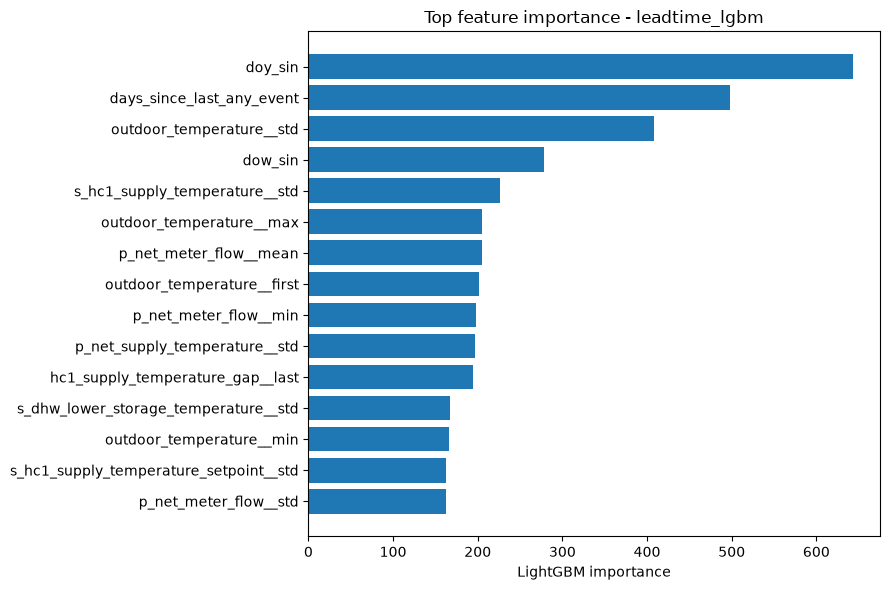

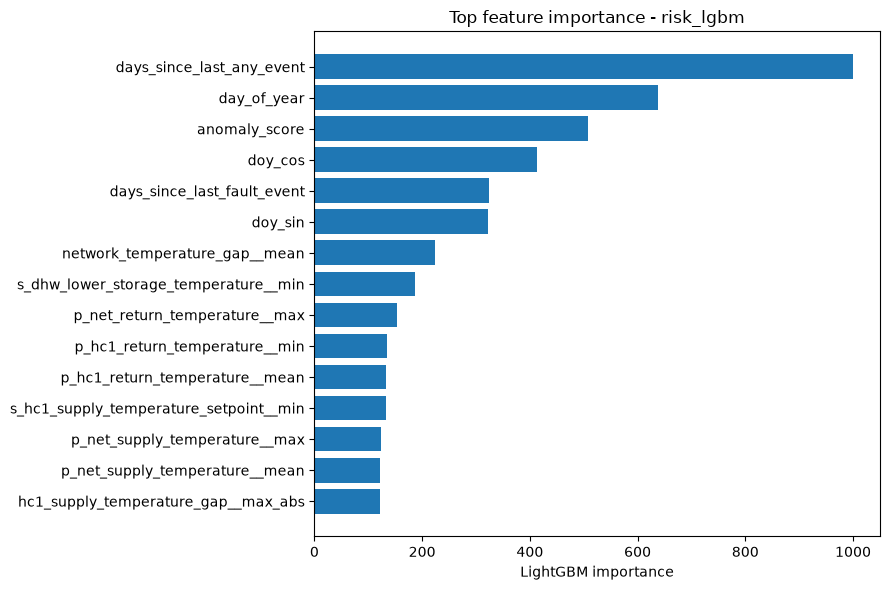

In [4]:
for model_name, model_frame in top_importance.groupby("model"):
    plot_frame = model_frame.head(15).sort_values("importance")
    plt.figure(figsize=(9, 6))
    plt.barh(plot_frame["feature"], plot_frame["importance"])
    plt.title(f"Top feature importance - {model_name}")
    plt.xlabel("LightGBM importance")
    plt.tight_layout()
    latest_path = OUTPUT_DIR / f"{model_name}_top_feature_importance.png"
    run_path = PLOT_DIR / f"{model_name}_top_feature_importance.png"
    plt.savefig(latest_path, dpi=150, bbox_inches="tight")
    plt.savefig(run_path, dpi=150, bbox_inches="tight")
    plt.show()

## 3. Window별 근거 feature 생성

각 window에서 모델 중요도가 높은 feature 중 해당 row의 값이 전체 분포에서 상대적으로 두드러지는 feature를 top evidence로 잡는다. SHAP이 아니므로 방향성 있는 국소 기여도는 아니지만, Priority Engine과 Agent가 우선순위 판단 근거로 사용할 수 있는 baseline 근거가 된다.

In [5]:
risk_top_features = top_importance[top_importance["model"].eq("risk_lgbm")]["feature"].head(25).tolist()
leadtime_top_features = top_importance[top_importance["model"].eq("leadtime_lgbm")]["feature"].head(25).tolist()
evidence_features = [feature for feature in dict.fromkeys(risk_top_features + leadtime_top_features) if feature in df.columns]

reference_mask = df["split_time_based"].eq("train") & df["label"].eq("normal")
reference = df.loc[reference_mask, evidence_features].apply(pd.to_numeric, errors="coerce")
feature_median = reference.median(numeric_only=True)
feature_iqr = reference.quantile(0.75) - reference.quantile(0.25)
feature_iqr = feature_iqr.replace(0, np.nan)

importance_lookup = importance_summary.groupby("feature")["importance_share"].max().to_dict()

def top_evidence_for_row(row: pd.Series, top_n: int = 5) -> list[dict]:
    items = []
    for feature in evidence_features:
        value = pd.to_numeric(row.get(feature), errors="coerce")
        if pd.isna(value):
            continue
        median = feature_median.get(feature, np.nan)
        iqr = feature_iqr.get(feature, np.nan)
        if pd.isna(median) or pd.isna(iqr) or iqr == 0:
            continue
        robust_z = (value - median) / iqr
        score = abs(robust_z) * float(importance_lookup.get(feature, 0.0))
        direction = "high" if robust_z > 0 else "low"
        items.append({
            "feature": feature,
            "value": float(value),
            "reference_median": float(median),
            "robust_z": float(robust_z),
            "direction": direction,
            "evidence_score": float(score),
            "family": family_map.get(feature, "모델결과/기타"),
        })
    return sorted(items, key=lambda item: item["evidence_score"], reverse=True)[:top_n]

explain_mask = df["risk_level"].isin(["high", "medium"]) | df["anomaly_label"].eq(1)
explain_candidates = df.loc[explain_mask].copy()
explain_candidates = explain_candidates.sort_values(["risk_probability", "anomaly_score"], ascending=[False, False]).head(500)

evidence_rows = []
for _, row in explain_candidates.iterrows():
    evidences = top_evidence_for_row(row, top_n=5)
    top_sensors = [item["feature"] for item in evidences]
    sensor_scores = {item["feature"]: item["evidence_score"] for item in evidences}
    pattern_notes = []
    if row.get("risk_class", 0) == 1:
        pattern_notes.append("risk threshold를 넘은 고위험 window")
    elif row.get("risk_level") == "medium":
        pattern_notes.append("risk probability가 중간 이상인 관찰 후보")
    if row.get("anomaly_label", 0) == 1:
        pattern_notes.append("Isolation Forest anomaly label이 1")
    if row.get("lead_time_bucket"):
        pattern_notes.append(f"leadtime 후보: {row.get('lead_time_bucket')}")

    evidence_rows.append({
        "manufacturer": row.get("manufacturer"),
        "substation_id": row.get("substation_id"),
        "source_file": row.get("source_file"),
        "window_start": row.get("window_start"),
        "window_end": row.get("window_end"),
        "label": row.get("label"),
        "split_time_based": row.get("split_time_based"),
        "configuration_type": row.get("configuration_type"),
        "season_bucket": row.get("season_bucket"),
        "anomaly_score": row.get("anomaly_score"),
        "anomaly_label": row.get("anomaly_label"),
        "risk_probability": row.get("risk_probability"),
        "risk_class": row.get("risk_class"),
        "risk_level": row.get("risk_level"),
        "lead_time_bucket": row.get("lead_time_bucket"),
        "lead_time_confidence": row.get("lead_time_confidence"),
        "top_sensors": json.dumps(top_sensors, ensure_ascii=False),
        "sensor_scores": json.dumps(sensor_scores, ensure_ascii=False),
        "evidence_details": json.dumps(evidences, ensure_ascii=False),
        "pattern_notes": " | ".join(pattern_notes),
        "explainability_run_id": RUN_ID,
        "source_model_run_id": metadata.get("run_id"),
    })

window_evidence = pd.DataFrame(evidence_rows)
display(window_evidence.head(20))

,manufacturer,substation_id,source_file,window_start,window_end,label,split_time_based,configuration_type,season_bucket,anomaly_score,anomaly_label,risk_probability,risk_class,risk_level,lead_time_bucket,lead_time_confidence,top_sensors,sensor_scores,evidence_details,pattern_notes,explainability_run_id,source_model_run_id
0,manufacturer 1,4,substation_4.csv,2016-11-15 18:00:00,2016-11-16 00:00:00,pre_fault,train,SH + DHW,autumn,-0.105387,0,0.999915,1,high,mid_24_72h,0.913996,"[""days_since_last_any_event"", ""day_of_year"", ""...","{""days_since_last_any_event"": 0.06266684753271...","[{""feature"": ""days_since_last_any_event"", ""val...",risk threshold를 넘은 고위험 window | leadtime 후보: m...,run_20260626_172308,run_20260626_155956
1,manufacturer 1,4,substation_4.csv,2016-11-11 18:00:00,2016-11-12 00:00:00,pre_fault,train,SH + DHW,autumn,-0.100520,0,0.999904,1,high,long_72h_plus,0.994007,"[""days_since_last_any_event"", ""p_net_return_te...","{""days_since_last_any_event"": 0.06375434163307...","[{""feature"": ""days_since_last_any_event"", ""val...",risk threshold를 넘은 고위험 window | leadtime 후보: l...,run_20260626_172308,run_20260626_155956
2,manufacturer 2,10,substation_10.csv,2019-10-11 18:00:00,2019-10-12 00:00:00,pre_fault,train,SH,autumn,0.035581,1,0.999896,1,high,mid_24_72h,0.946100,"[""p_net_meter_flow__min"", ""p_net_meter_flow__m...","{""p_net_meter_flow__min"": 0.22554768309051676,...","[{""feature"": ""p_net_meter_flow__min"", ""value"":...",risk threshold를 넘은 고위험 window | Isolation Fore...,run_20260626_172308,run_20260626_155956
3,manufacturer 2,10,substation_10.csv,2019-10-13 00:00:00,2019-10-13 06:00:00,pre_fault,train,SH,autumn,0.040392,1,0.999894,1,high,mid_24_72h,0.833630,"[""p_net_meter_flow__min"", ""p_net_meter_flow__m...","{""p_net_meter_flow__min"": 0.2389931829013199, ...","[{""feature"": ""p_net_meter_flow__min"", ""value"":...",risk threshold를 넘은 고위험 window | Isolation Fore...,run_20260626_172308,run_20260626_155956
4,manufacturer 2,10,substation_10.csv,2019-10-12 06:00:00,2019-10-12 12:00:00,pre_fault,train,SH,autumn,0.042524,1,0.999894,1,high,mid_24_72h,0.955429,"[""p_net_meter_flow__min"", ""p_net_meter_flow__m...","{""p_net_meter_flow__min"": 0.24475553996309268,...","[{""feature"": ""p_net_meter_flow__min"", ""value"":...",risk threshold를 넘은 고위험 window | Isolation Fore...,run_20260626_172308,run_20260626_155956
5,manufacturer 1,4,substation_4.csv,2016-11-17 18:00:00,2016-11-18 00:00:00,pre_fault,train,SH + DHW,autumn,-0.104901,0,0.999893,1,high,short_0_24h,0.930012,"[""days_since_last_any_event"", ""day_of_year"", ""...","{""days_since_last_any_event"": 0.06212310048254...","[{""feature"": ""days_since_last_any_event"", ""val...",risk threshold를 넘은 고위험 window | leadtime 후보: s...,run_20260626_172308,run_20260626_155956
6,manufacturer 2,10,substation_10.csv,2019-10-13 12:00:00,2019-10-13 18:00:00,pre_fault,train,SH,autumn,0.048476,1,0.999891,1,high,short_0_24h,0.941257,"[""p_net_meter_flow__min"", ""p_net_meter_flow__m...","{""p_net_meter_flow__min"": 0.24859711133760787,...","[{""feature"": ""p_net_meter_flow__min"", ""value"":...",risk threshold를 넘은 고위험 window | Isolation Fore...,run_20260626_172308,run_20260626_155956
7,manufacturer 2,10,substation_10.csv,2019-10-11 06:00:00,2019-10-11 12:00:00,pre_fault,train,SH,autumn,0.061695,1,0.999888,1,high,mid_24_72h,0.950052,"[""p_net_meter_flow__mean"", ""p_net_meter_flow__...","{""p_net_meter_flow__mean"": 0.16957464134268907...","[{""feature"": ""p_net_meter_flow__mean"", ""value""...",risk threshold를 넘은 고위험 window | Isolation Fore...,run_20260626_172308,run_20260626_155956
8,manufacturer 2,10,substation_10.csv,2019-10-12 12:00:00,2019-10-12 18:00:00,pre_fault,train,SH,autumn,0.091224,1,0.999887,1,high,mid_24_72h,0.980272,"[""anomaly_score"", ""p_net_meter_flow__mean"", ""p...","{""anomaly_score"": 0.18620138384941207, ""p_net_...","[{""feature"": ""anomaly_score"", ""value"": 0.09122...",risk threshold를 넘은 고위험 window | Isolation Fore...,run_20260626_172308,

## 4. Holdout 과대위험 window 전용 근거

우선순위 모델 관점에서 중요한 오류는 정상 window가 지나치게 높은 위험 입력값을 받는 경우다. 따라서 holdout 정상 window 중 risk threshold를 넘은 과대위험 사례를 따로 분리해 evidence를 저장한다.

In [6]:
fp_mask = (
    df["split_time_based"].eq("holdout")
    & df["label"].eq("normal")
    & df["risk_class"].eq(1)
)
false_positive_windows = df.loc[fp_mask].copy()
false_positive_windows = false_positive_windows.sort_values("risk_probability", ascending=False)

fp_rows = []
for _, row in false_positive_windows.iterrows():
    evidences = top_evidence_for_row(row, top_n=8)
    top_sensors = [item["feature"] for item in evidences]
    sensor_scores = {item["feature"]: item["evidence_score"] for item in evidences}
    fp_rows.append({
        "manufacturer": row.get("manufacturer"),
        "substation_id": row.get("substation_id"),
        "source_file": row.get("source_file"),
        "window_start": row.get("window_start"),
        "window_end": row.get("window_end"),
        "label": row.get("label"),
        "split_time_based": row.get("split_time_based"),
        "split_regime_based": row.get("split_regime_based"),
        "manufacturer": row.get("manufacturer"),
        "configuration_type": row.get("configuration_type"),
        "season_bucket": row.get("season_bucket"),
        "anomaly_score": row.get("anomaly_score"),
        "anomaly_label": row.get("anomaly_label"),
        "risk_probability": row.get("risk_probability"),
        "risk_threshold": row.get("risk_threshold"),
        "lead_time_bucket": row.get("lead_time_bucket"),
        "lead_time_confidence": row.get("lead_time_confidence"),
        "top_sensors": json.dumps(top_sensors, ensure_ascii=False),
        "sensor_scores": json.dumps(sensor_scores, ensure_ascii=False),
        "evidence_details": json.dumps(evidences, ensure_ascii=False),
        "diagnostic_label": "holdout_overestimated_risk",
        "pattern_notes": "정상 holdout window가 risk threshold를 넘어 priority 입력에서 과대평가될 수 있음",
        "explainability_run_id": RUN_ID,
        "source_model_run_id": metadata.get("run_id"),
    })

false_positive_window_evidence = pd.DataFrame(fp_rows)
decision_feature_evidence = window_evidence.copy()
decision_feature_evidence["priority_input_role"] = "risk_or_anomaly_evidence"
if not false_positive_window_evidence.empty:
    overestimated = false_positive_window_evidence.copy()
    overestimated["priority_input_role"] = "overestimated_risk_diagnostic"
    decision_feature_evidence = pd.concat([decision_feature_evidence, overestimated], ignore_index=True, sort=False)

fp_feature_rows = []
for _, fp_row in false_positive_window_evidence.iterrows():
    for item in json.loads(fp_row["evidence_details"]):
        fp_feature_rows.append({
            "feature": item["feature"],
            "family": item["family"],
            "direction": item["direction"],
            "evidence_score": item["evidence_score"],
            "abs_robust_z": abs(item["robust_z"]),
        })

if fp_feature_rows:
    false_positive_feature_summary = pd.DataFrame(fp_feature_rows).groupby(
        ["feature", "family", "direction"], as_index=False
    ).agg(
        count=("feature", "size"),
        mean_evidence_score=("evidence_score", "mean"),
        max_evidence_score=("evidence_score", "max"),
        mean_abs_robust_z=("abs_robust_z", "mean"),
    ).sort_values(["count", "mean_evidence_score"], ascending=[False, False]).reset_index(drop=True)
else:
    false_positive_feature_summary = pd.DataFrame(columns=["feature", "family", "direction", "count", "mean_evidence_score", "max_evidence_score", "mean_abs_robust_z"])

display(false_positive_window_evidence.head(20))
display(false_positive_feature_summary.head(20))

,manufacturer,substation_id,source_file,window_start,window_end,label,split_time_based,split_regime_based,configuration_type,season_bucket,anomaly_score,anomaly_label,risk_probability,risk_threshold,lead_time_bucket,lead_time_confidence,top_sensors,sensor_scores,evidence_details,diagnostic_label,pattern_notes,explainability_run_id,source_model_run_id
0,manufacturer 2,26,substation_26.csv,2020-03-08 12:00:00,2020-03-08 18:00:00,normal,holdout,train,SH + DHW,spring,-0.096230,0,0.994334,0.95,mid_24_72h,0.937055,"[""days_since_last_any_event"", ""doy_sin"", ""day_...","{""days_since_last_any_event"": 0.07863299789561...","[{""feature"": ""days_since_last_any_event"", ""val...",holdout_overestimated_risk,정상 holdout window가 risk threshold를 넘어 priority...,run_20260626_172308,run_20260626_155956
1,manufacturer 2,52,substation_52.csv,2020-03-11 06:00:00,2020-03-11 12:00:00,normal,holdout,train,SH + DHW,spring,-0.051551,0,0.994179,0.95,short_0_24h,0.757698,"[""outdoor_temperature__std"", ""doy_sin"", ""day_o...","{""outdoor_temperature__std"": 0.048962171723474...","[{""feature"": ""outdoor_temperature__std"", ""valu...",holdout_overestimated_risk,정상 holdout window가 risk threshold를 넘어 priority...,run_20260626_172308,run_20260626_155956
2,manufacturer 2,26,substation_26.csv,2020-03-08 00:00:00,2020-03-08 06:00:00,normal,holdout,train,SH + DHW,spring,-0.074446,0,0.994157,0.95,mid_24_72h,0.828724,"[""days_since_last_any_event"", ""doy_sin"", ""day_...","{""days_since_last_any_event"": 0.07876893465815...","[{""feature"": ""days_since_last_any_event"", ""val...",holdout_overestimated_risk,정상 holdout window가 risk threshold를 넘어 priority...,run_20260626_172308,run_20260626_155956
3,manufacturer 2,26,substation_26.csv,2020-03-07 12:00:00,2020-03-07 18:00:00,normal,holdout,train,SH + DHW,spring,-0.098902,0,0.992195,0.95,mid_24_72h,0.991806,"[""days_since_last_any_event"", ""day_of_year"", ""...","{""days_since_last_any_event"": 0.07890487142070...","[{""feature"": ""days_since_last_any_event"", ""val...",holdout_overestimated_risk,정상 holdout window가 risk threshold를 넘어 priority...,run_20260626_172308,run_20260626_155956
4,manufacturer 2,26,substation_26.csv,2020-03-08 06:00:00,2020-03-08 12:00:00,normal,holdout,train,SH + DHW,spring,-0.082517,0,0.991732,0.95,mid_24_72h,0.626290,"[""days_since_last_any_event"", ""doy_sin"", ""day_...","{""days_since_last_any_event"": 0.07870096627688...","[{""feature"": ""days_since_last_any_event"", ""val...",holdout_overestimated_risk,정상 holdout window가 risk threshold를 넘어 priority...,run_20260626_172308,run_20260626_155956
5,manufacturer 2,26,substation_26.csv,2020-03-06 06:00:00,2020-03-06 12:00:00,normal,holdout,train,SH + DHW,spring,-0.083938,0,0.991297,0.95,mid_24_72h,0.962841,"[""days_since_last_any_event"", ""day_of_year"", ""...","{""days_since_last_any_event"": 0.07924471332706...","[{""feature"": ""days_since_last_any_event"", ""val...",holdout_overestimated_risk,정상 holdout window가 risk threshold를 넘어 priority...,run_20260626_172308,run_20260626_155956
6,manufacturer 2,26,substation_26.csv,2020-03-06 12:00:00,2020-03-06 18:00:00,normal,holdout,train,SH + DHW,spring,-0.072770,0,0.990724,0.95,mid_24_72h,0.926102,"[""days_since_last_any_event"", ""day_of_year"", ""...","{""days_since_last_any_event"": 0.07917674494578...","[{""feature"": ""days_since_last_any_event"", ""val...",holdout_overestimated_risk,정상 holdout window가 risk threshold를 넘어 priority...,run_20260626_172308,run_20260626_155956
7,manufacturer 2,26,substation_26.csv,2020-03-06 00:00:00,2020-03-06 06:00:00,normal,holdout,train,SH + DHW,spring,-0.090023,0,0.990004,0.95,mid_24_72h,0.965776,"[""days_since_last_any_event"", ""day_of_year"", ""...","{""days_since_last_any_event"": 0.07931268170833...","[{""feature"": ""days_since_last_any_event"", ""val...",holdout_overestimated_risk,정상 holdout window가 risk threshold를 넘어 priority...,run_20260626_172308,run_20260626_155956
8,manufacturer 2,26,substation_26.csv,2020-03-08 18:00:00,2020-03-09 00:00:00,

,feature,family,direction,count,mean_evidence_score,max_evidence_score,mean_abs_robust_z
0,doy_sin,시간/주기,high,31,0.037842,0.039702,0.642482
1,day_of_year,시간/주기,low,31,0.037493,0.039291,0.505182
2,days_since_last_any_event,이벤트 이력,low,21,0.078652,0.080060,0.675067
3,s_hc1_supply_temperature__std,센서 통계,high,18,0.029704,0.045467,1.434845
4,s_hc1_supply_temperature_setpoint__std,센서 통계,high,15,0.021633,0.031208,1.448874
5,p_net_supply_temperature__std,센서 통계,high,12,0.035268,0.074102,1.954441
6,anomaly_score,모델결과/기타,high,11,0.040389,0.062091,0.682395
7,p_net_meter_flow__mean,센서 통계,high,10,0.031162,0.048768,1.659509
8,outdoor_temperature__std,센서 통계,high,8,0.100334,0.182543,2.684683
9,p_net_meter_flow__min,센서 통계,high,8,0.045462,0.084562,2.506610


## 5. 과대위험 group 진단

06에서 확인한 group별 과대위험 판단 문제를 07에서 우선 설명 대상으로 정리한다.

In [7]:
false_positive_groups = group_diagnostics.copy()
false_positive_groups = false_positive_groups[
    false_positive_groups["split"].eq("holdout") & (false_positive_groups["false_positive_rate"] > 0)
].sort_values(["false_positive_rate", "false_positive"], ascending=[False, False]).reset_index(drop=True)

def make_group_note(row: pd.Series) -> str:
    return (
        f"holdout {row['group_column']}={row['group_value']} 그룹에서 "
        f"정상 window 과대위험 비율 {row['false_positive_rate']:.3f}, "
        f"과대위험 {int(row['false_positive'])}건이 발생했다. "
        "해당 그룹은 08 decision_features 또는 후속 Priority Engine에서 별도 보정 후보로 본다."
    )

false_positive_groups["diagnostic_note"] = false_positive_groups.apply(make_group_note, axis=1)
display(false_positive_groups.head(20))

,threshold,accuracy,precision,recall,f1,average_precision,roc_auc,false_positive_rate,true_negative,false_positive,false_negative,true_positive,run_id,split,group_column,group_value,rows,diagnostic_note
0,0.95,0.300000,0.000000,0.00000,0.000000,0.277882,0.117911,0.473684,30,27,43,0,run_20260626_155956,holdout,split_regime_based,train,100,holdout split_regime_based=train 그룹에서 정상 windo...
1,0.95,0.618280,0.000000,0.00000,0.000000,0.136608,0.163667,0.206897,115,30,41,0,run_20260626_155956,holdout,manufacturer,manufacturer 2,186,holdout manufacturer=manufacturer 2 그룹에서 정상 wi...
2,0.95,0.670635,0.408163,0.27027,0.325203,0.510212,0.680003,0.162921,149,29,54,20,run_20260626_155956,holdout,configuration_type,SH + DHW,252,holdout configuration_type=SH + DHW 그룹에서 정상 wi...
3,0.95,0.640569,0.000000,0.00000,0.000000,0.194186,0.368075,0.142857,180,30,71,0,run_20260626_155956,holdout,season_bucket,spring,281,holdout season_bucket=spring 그룹에서 정상 window 과대...
4,0.95,0.790476,0.000000,0.00000,0.000000,0.199301,0.580171,0.034884,83,3,19,0,run_20260626_155956,holdout,split_regime_based,validation,105,holdout split_regime_based=validation 그룹에서 정상 ...
5,0.95,0.775862,0.000000,0.00000,0.000000,0.119992,0.000000,0.021739,45,1,12,0,run_20260626_155956,holdout,configuration_type,SH,58,holdout configuration_type=SH 그룹에서 정상 window 과...


## 6. 저장

07 결과는 최신본과 run별 파일을 함께 저장한다.

In [8]:
def save_latest_and_run(df_out: pd.DataFrame, latest_name: str):
    latest_path = OUTPUT_DIR / latest_name
    run_path = RUN_DIR / latest_name
    df_out.to_csv(latest_path, index=False)
    df_out.to_csv(run_path, index=False)
    return latest_path, run_path

save_latest_and_run(importance_summary, "feature_importance_summary.csv")
save_latest_and_run(top_importance, "top_feature_importance.csv")
save_latest_and_run(family_importance, "feature_family_importance.csv")
save_latest_and_run(window_evidence, "window_evidence.csv")
save_latest_and_run(decision_feature_evidence, "decision_feature_evidence.csv")
save_latest_and_run(false_positive_window_evidence, "false_positive_window_evidence.csv")
save_latest_and_run(false_positive_feature_summary, "false_positive_feature_summary.csv")
save_latest_and_run(false_positive_groups, "false_positive_group_diagnostics.csv")

explainability_metadata = {
    "run_id": RUN_ID,
    "created_at": datetime.now().isoformat(timespec="seconds"),
    "source_model_run_id": metadata.get("run_id"),
    "source_risk_model_version": metadata.get("risk_model_version"),
    "source_leadtime_model_version": metadata.get("leadtime_model_version"),
    "method": "LightGBM feature importance + robust deviation evidence baseline",
    "notes": [
        "SHAP 기반 국소 설명이 아니라 feature importance와 normal reference 대비 벗어난 정도를 결합한 baseline 근거다.",
        "07 결과는 08 decision_features/export의 top_sensors, sensor_scores, pattern_notes 후보로 사용한다.",
    ],
    "output_files": [
        "feature_importance_summary.csv",
        "top_feature_importance.csv",
        "feature_family_importance.csv",
        "window_evidence.csv",
        "decision_feature_evidence.csv",
        "false_positive_window_evidence.csv",
        "false_positive_feature_summary.csv",
        "false_positive_group_diagnostics.csv",
    ],
}

for path in [OUTPUT_DIR / "explainability_metadata.json", RUN_DIR / "explainability_metadata.json"]:
    path.write_text(json.dumps(explainability_metadata, ensure_ascii=False, indent=2), encoding="utf-8")

print("saved to:", OUTPUT_DIR)
print("run dir:", RUN_DIR)

saved to: c:\project3.0_2\data\processed\ml_explainability
run dir: c:\project3.0_2\data\processed\ml_explainability\runs\run_20260626_172308
